# Project 4 - Healthcare Treatment Effectiveness Analysis

**Domain:** Healthcare  
**Data:** Simulated and de-identified  
**Purpose:** Descriptive portfolio analysis, not clinical guidance.

## 1. Setup and loading

In [1]:
from pathlib import Path
import sys,pandas as pd,numpy as np
ROOT=Path.cwd() if (Path.cwd()/'src').exists() else Path.cwd().parent
sys.path.insert(0,str(ROOT))
from src.healthcare_analysis import validate_healthcare_data,clean_healthcare_data,calculate_healthcare_kpis
raw=pd.read_csv(ROOT/'data/project4_healthcare/healthcare_raw.csv')
raw.head()

,patient_id,admission_date,hospital,age,gender,condition,severity,treatment,baseline_score,followup_score,length_of_stay_days,treatment_cost_inr,readmitted_30d,satisfaction_score
0,PAT-00001,2024-09-26,Regional Care,58,Female,Diabetes,Mild,Combined Therapy,60.5,47.2,10.0,77282.0,No,7.9
1,PAT-00002,2024-03-28,Central Hospital,56,Male,Diabetes,Severe,Standard Care,86.3,92.6,13.0,73249.0,Yes,5.7
2,PAT-00003,2024-04-09,Central Hospital,71,Male,Cardiac Condition,Moderate,Medication A,74.4,60.9,9.0,66579.0,No,5.4
3,PAT-00004,2024-05-07,Community Hospital,79,Female,Respiratory Infection,Moderate,Combined Therapy,72.2,53.1,8.0,72642.0,No,6.5
4,PAT-00005,2024-02-07,City Medical,27,Male,Respiratory Infection,Moderate,Medication B,49.7,41.6,9.0,51122.0,No,6.5


## 2. Data quality and cleaning

In [2]:
raw_validation=validate_healthcare_data(raw)
pd.Series(raw_validation)

rows                                                                      1802
columns                                                                     14
missing_required_columns                                                    []
duplicate_patient_ids                                                        2
missing_values               {'length_of_stay_days': 1, 'treatment_cost_inr...
invalid_age_rows                                                             0
invalid_baseline_rows                                                        0
invalid_followup_rows                                                        0
invalid_stay_rows                                                            0
invalid_cost_rows                                                            0
invalid_satisfaction_rows                                                    0
dtype: object

In [3]:
patients=clean_healthcare_data(raw)
print(f'{len(raw):,} raw rows -> {len(patients):,} cleaned encounters')
validate_healthcare_data(patients)

1,802 raw rows -> 1,800 cleaned encounters


{'rows': 1800,
 'columns': 19,
 'missing_required_columns': [],
 'duplicate_patient_ids': 0,
 'missing_values': {},
 'invalid_age_rows': 0,
 'invalid_baseline_rows': 0,
 'invalid_followup_rows': 0,
 'invalid_stay_rows': 0,
 'invalid_cost_rows': 0,
 'invalid_satisfaction_rows': 0}

## 3. Descriptive statistics and KPIs

In [4]:
kpis=calculate_healthcare_kpis(patients)
pd.Series(kpis).to_frame('Value')

,Value
patients,1800
average_age,55.6
mean_clinical_improvement,10.85
median_clinical_improvement,10.7
favourable_outcome_rate_pct,50.17
readmission_rate_pct,11.56
average_length_of_stay_days,7.85
median_treatment_cost_inr,58577.5
average_satisfaction,6.49
highest_improvement_treatment,Combined Therapy


In [5]:
patients[['age','baseline_score','followup_score','clinical_improvement','length_of_stay_days','treatment_cost_inr','satisfaction_score']].describe().round(2)

,age,baseline_score,followup_score,clinical_improvement,length_of_stay_days,treatment_cost_inr,satisfaction_score
count,1800.00,1800.00,1800.00,1800.00,1800.00,1800.00,1800.00
mean,55.60,65.71,54.86,10.85,7.85,58297.57,6.49
std,16.56,12.60,15.76,7.69,2.86,18357.75,1.41
min,18.00,28.80,12.50,-12.00,1.00,5000.00,2.10
25%,45.00,56.70,44.28,5.70,6.00,45698.50,5.50
50%,56.00,65.50,55.15,10.70,8.00,58577.50,6.50
75%,67.00,74.80,65.62,15.90,10.00,71074.25,7.40
max,92.00,98.00,100.00,36.60,18.00,118220.00,10.00


## 4. Stratified treatment outcomes

In [6]:
patients.groupby(['condition','severity','treatment']).agg(patients=('patient_id','count'),baseline=('baseline_score','mean'),improvement=('clinical_improvement','mean'),favourable_rate=('favourable_outcome',lambda s:(s=='Yes').mean()*100),readmission_rate=('readmitted_30d',lambda s:(s=='Yes').mean()*100)).round(2)

patients  baseline  \
condition             severity treatment                              
Cardiac Condition     Mild     Combined Therapy        36     57.90   
                               Medication A            35     53.89   
                               Medication B            21     52.58   
                               Standard Care           35     56.22   
                      Moderate Combined Therapy        44     68.74   
                               Medication A            40     67.63   
                               Medication B            35     68.67   
                               Standard Care           35     69.99   
                      Severe   Combined Therapy        20     81.28   
                               Medication A            13     80.06   
                               Medication B            15     82.29   
                               Standard Care           15     78.35   
Diabetes              Mild     Combined Therapy        47     54.33   
                               Medication A            38     54.72   
                               Medication B            41     56.50   
                               Standard Care           49     57.12   
                      Moderate Combined Therapy        62     67.89   
                               Medication A            47     66.73   
                               Medication B            47     69.32   
                               Standard Care           67     67.98   
                      Severe   Combined Therapy        28     77.90   
                               Medication A            20     79.70   
                               Medication B            21     79.77   
                               Standard Care           21     79.89   
Hypertension          Mild     Combined Therapy        42     55.03   
                               Medication A            45     55.81   
                               Medication B            34     54.90   
                               Standard Care           52     53.85   
                      Moderate Combined Therapy        51     67.27   
                               Medication A            52     67.87   
                               Medication B            58     68.97   
                               Standard Care           52     67.71   
                      Severe   Combined Therapy        26     79.14   
                               Medication A            27     82.06   
                               Medication B            19     82.83   
                               Standard Care           27     77.61   
Respiratory Infection Mild     Combined Therapy        50     55.62   
                               Medication A            49     56.45   
                               Medication B            35     52.70   
                               Standard Care           62     55.81   
                      Moderate Combined Therapy        50     66.87   
                               Medication A            45     68.10   
                               Medication B            40     68.94   
                               Standard Care           60     68.72   
                      Severe   Combined Therapy        28     84.73   
                               Medication A            20     82.59   
                               Medication B            22     79.87   
                               Standard Care           22     77.82   

                                                 improvement  favourable_rate  \
condition             severity treatment                                        
Cardiac Condition     Mild     Combined Therapy        16.93            77.78   
                               Medication A            14.03            60.00   
                               Medication B            11.72            47.62   
                               Standard Care            9.61            45.71   
            

## 5. Cost, stay, and experience

In [7]:
patients.groupby('treatment').agg(cost_median=('treatment_cost_inr','median'),stay_mean=('length_of_stay_days','mean'),satisfaction_mean=('satisfaction_score','mean')).round(2)

,cost_median,stay_mean,satisfaction_mean
treatment,,,
Combined Therapy,69503.0,7.81,6.85
Medication A,57052.0,7.90,6.49
Medication B,61227.0,7.99,6.44
Standard Care,47053.0,7.72,6.19


## 6. Correlations

In [8]:
patients[['age','baseline_score','clinical_improvement','length_of_stay_days','treatment_cost_inr','satisfaction_score']].corr().round(3)

,age,baseline_score,clinical_improvement,length_of_stay_days,treatment_cost_inr,satisfaction_score
age,1.000,0.191,-0.028,0.298,0.234,-0.118
baseline_score,0.191,1.000,-0.157,0.448,0.391,-0.179
clinical_improvement,-0.028,-0.157,1.000,-0.144,0.040,0.511
length_of_stay_days,0.298,0.448,-0.144,1.000,0.812,-0.240
treatment_cost_inr,0.234,0.391,0.040,0.812,1.000,-0.127
satisfaction_score,-0.118,-0.179,0.511,-0.240,-0.127,1.000


## 7. Subgroup checks

In [9]:
patients.groupby(['age_group','gender'],observed=True).agg(patients=('patient_id','count'),improvement=('clinical_improvement','mean'),readmission=('readmitted_30d',lambda s:(s=='Yes').mean()*100)).round(2)

patients  improvement  readmission
age_group gender                                    
18-39     Female       159        12.51         4.40
          Male         143        11.53         3.50
40-59     Female       364        10.90         8.52
          Male         384        10.25         9.64
60-79     Female       294        11.18        14.63
          Male         318         9.83        18.87
80+       Female        69        11.36        15.94
          Male          69        11.58        20.29

## 8. Visualizations

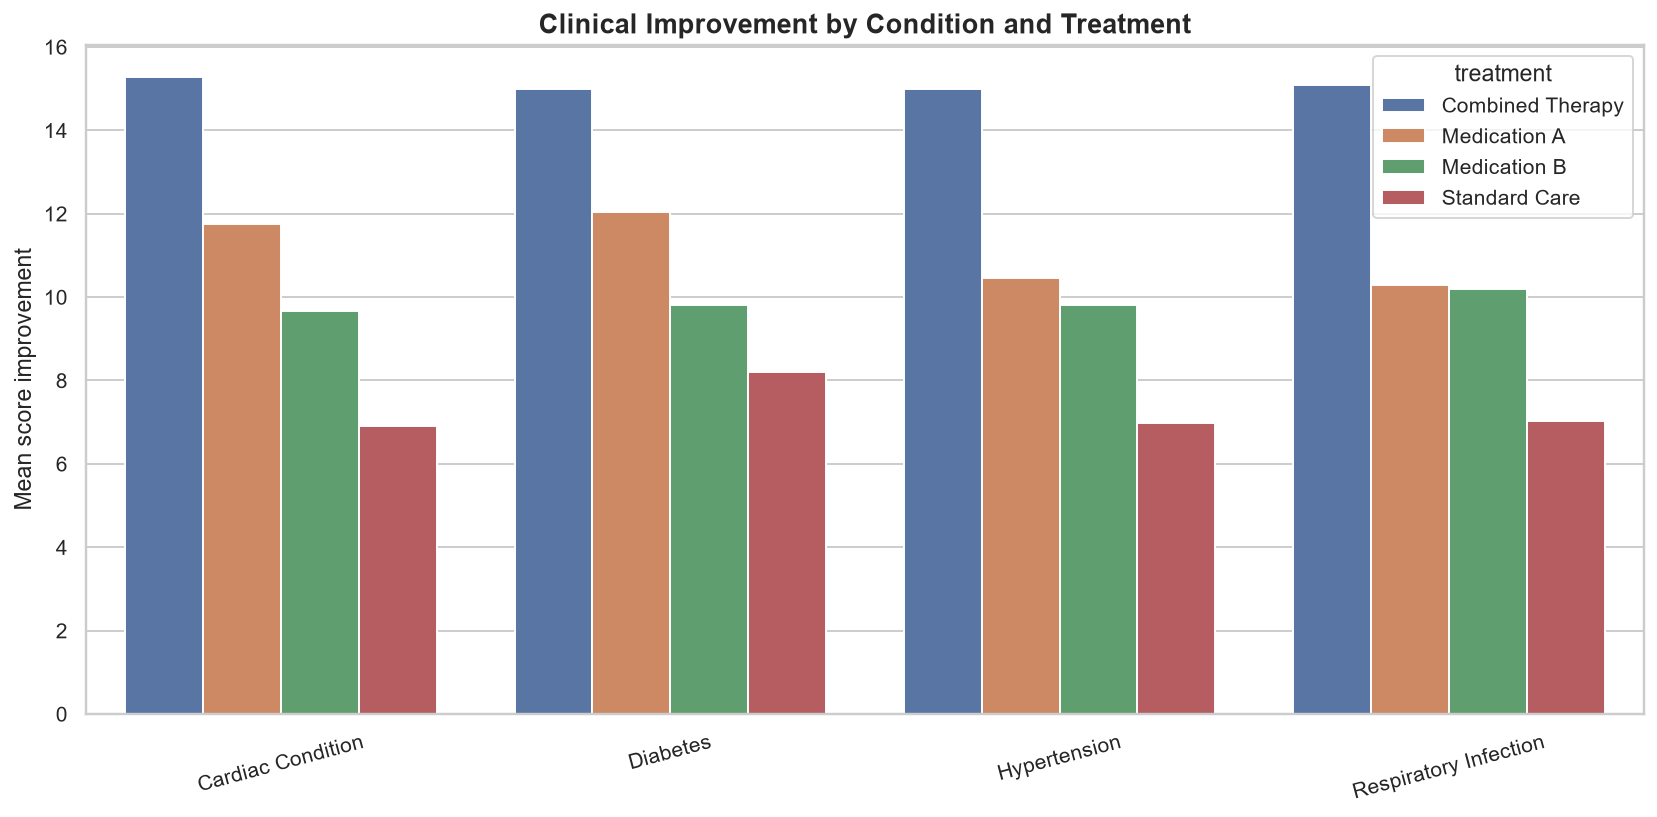

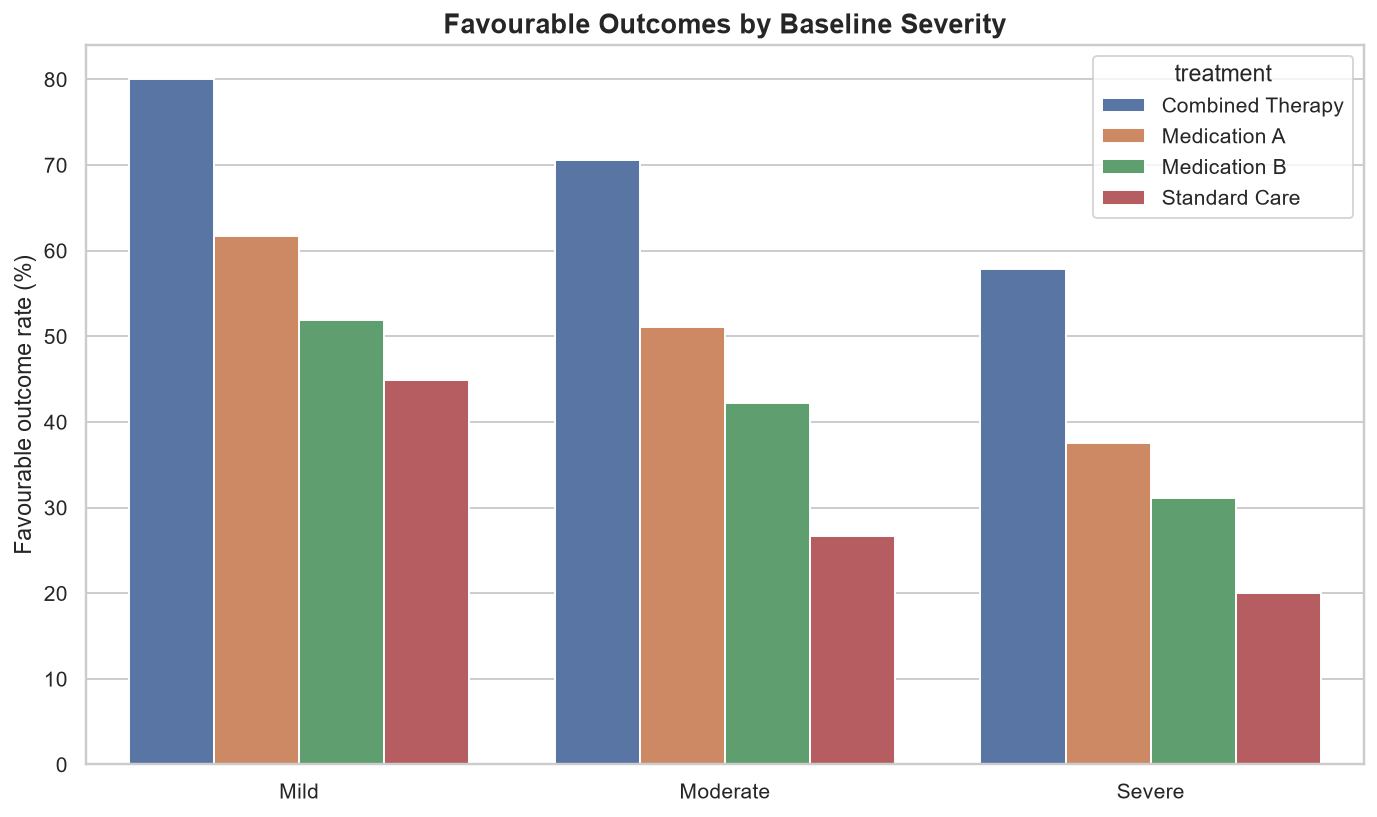

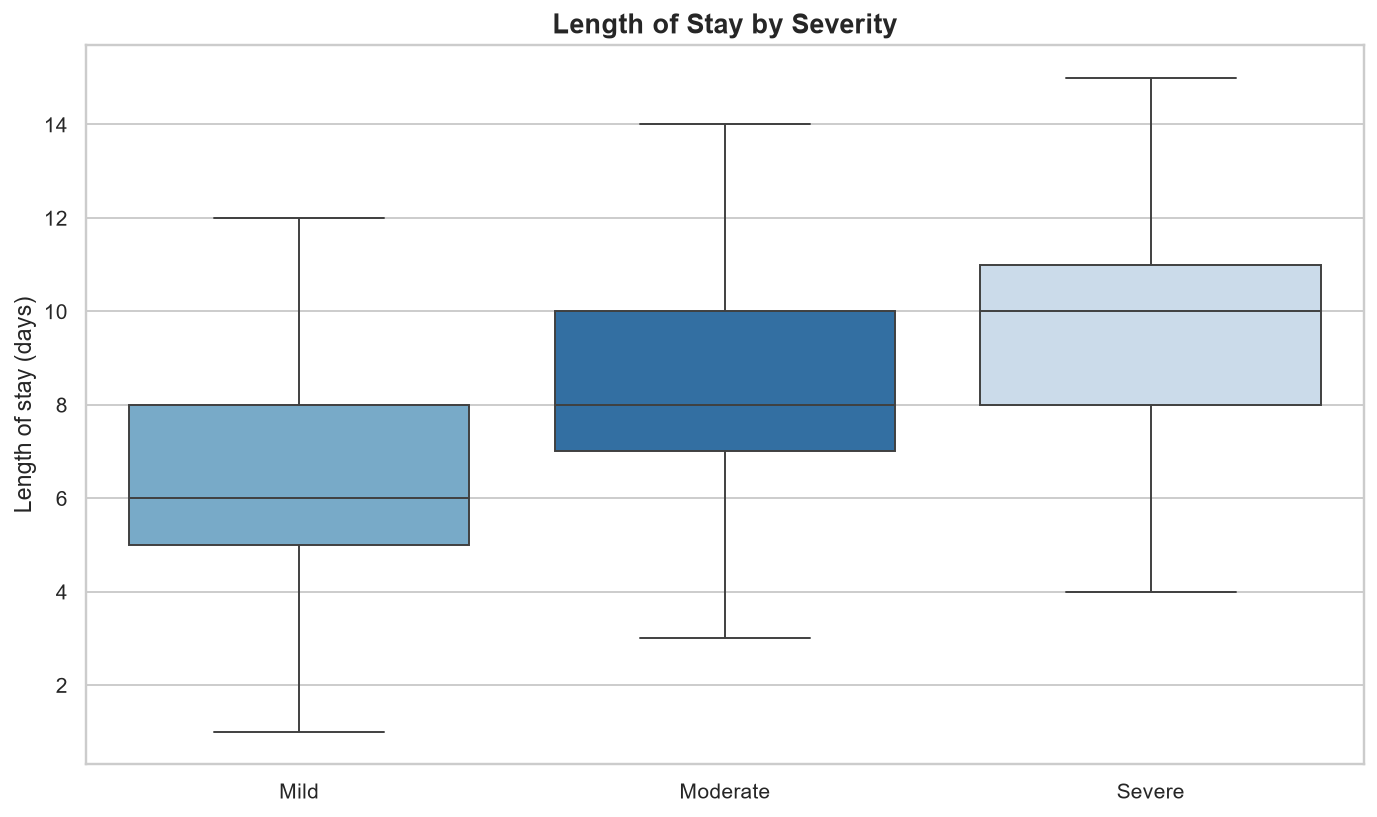

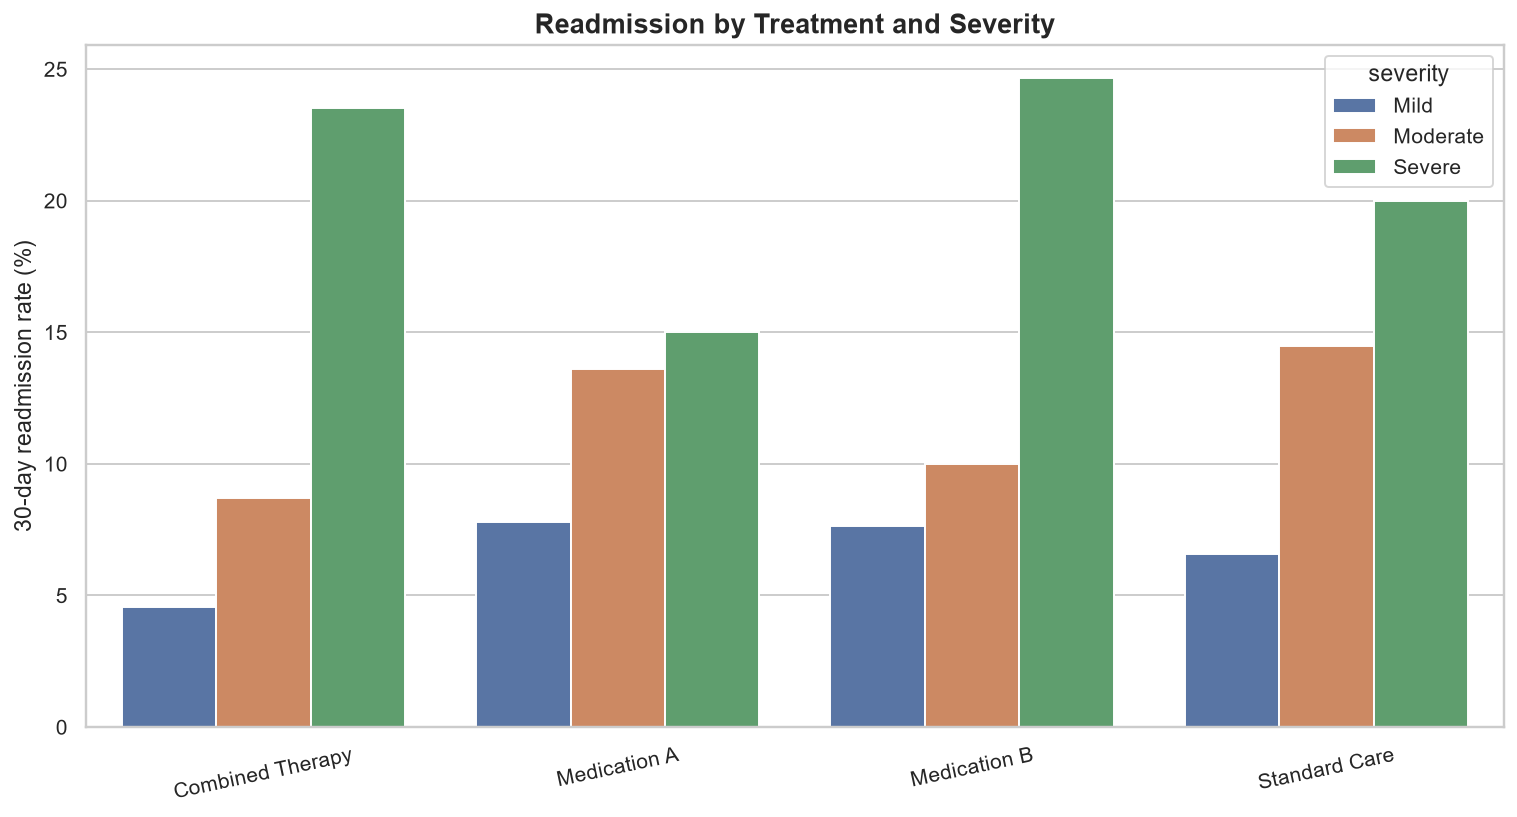

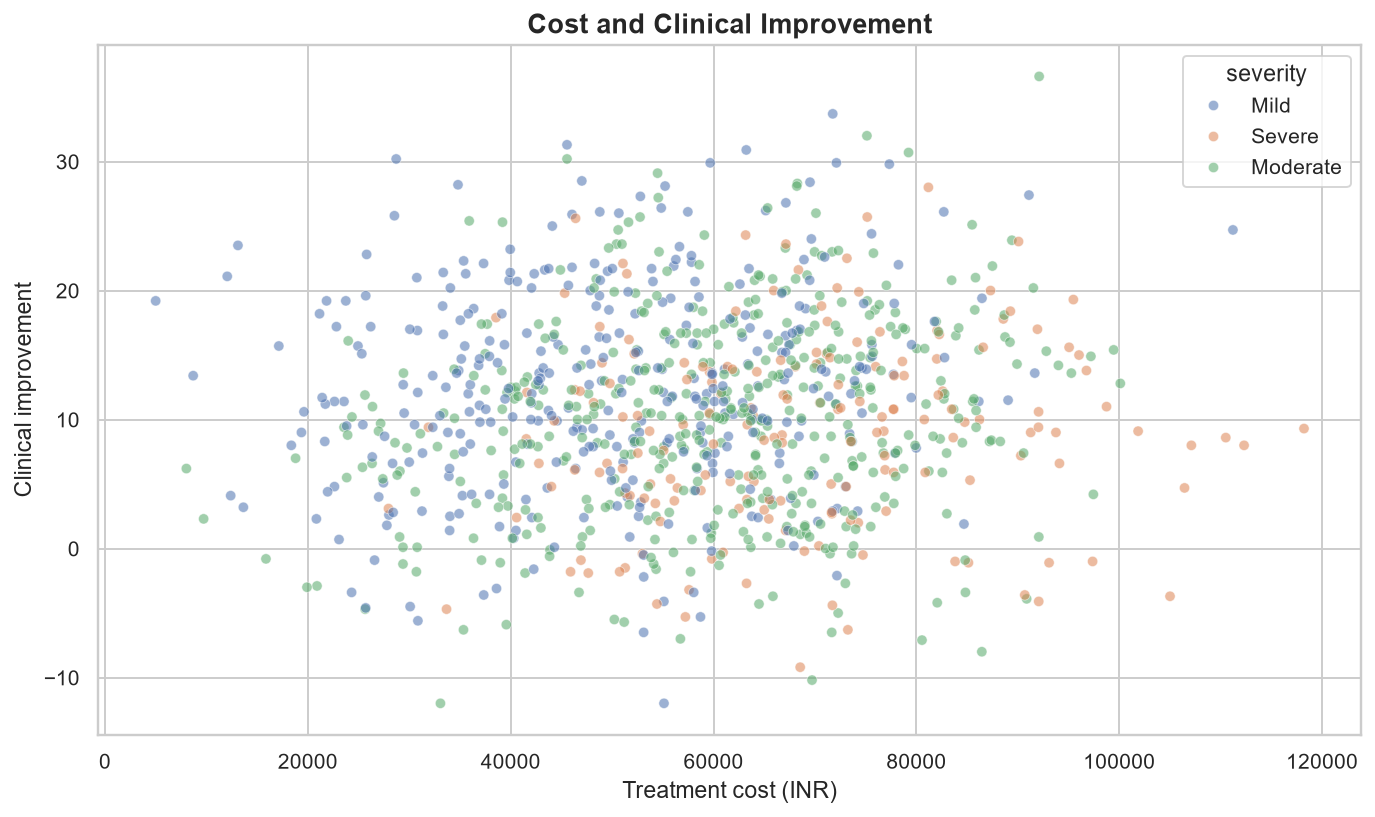

In [10]:
from IPython.display import display,Image
for chart in sorted((ROOT/'visualizations/project4_healthcare').glob('*.png')): display(Image(filename=str(chart),width=850))

## 9. Recommendations
1. Compare treatments within condition and severity.
2. Review high-readmission groups clinically.
3. Balance improvement, safety, stay, cost, and experience.
4. Audit missingness and subgroup representation.
5. Require clinician oversight and risk adjustment for real use.

## 10. Safety and limitations
This simulated observational analysis cannot establish treatment causality and must not guide patient care.